# 🤖 **Page Importance CNN Classifier**

## **Purpose:**
Train a lightweight CNN to classify PDF pages as:
- ✅ **Important** (content pages)
- ❌ **Not Important** (cover, TOC, etc.)

## **Architecture:**
- Small CNN (MobileNetV2-based)
- Data augmentation for small dataset
- Transfer learning from ImageNet
- Fast training (~5-10 minutes)

---

## 🔧 **1. Setup & Installation**

In [1]:
# Install dependencies
!pip install -q torch torchvision pillow matplotlib scikit-learn

print("✅ Dependencies installed!")

# Check GPU availability
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower.")
    print("   💡 Enable GPU: Runtime → Change runtime type → GPU")

✅ Dependencies installed!

🖥️  Using device: cuda
   GPU: Tesla T4


## 📂 **2. Mount Google Drive & Load Data**

In [2]:
from google.colab import drive
import os
from pathlib import Path
import json

# Mount Google Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✅ Google Drive mounted!")
else:
    print("✅ Google Drive already mounted!")

# Configure paths
BASE_DIR = Path("/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/")
PAGE_CLASSIFIER_DATA = BASE_DIR / "data" / "page_classifier_data"
IMAGES_DIR = PAGE_CLASSIFIER_DATA / "images"
LABELS_FILE = PAGE_CLASSIFIER_DATA / "labels" / "labels.json"
MODEL_SAVE_DIR = BASE_DIR / "models" / "extra" / "page_classifier"

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📂 Data Directory: {IMAGES_DIR}")
print(f"📄 Labels File: {LABELS_FILE}")
print(f"💾 Model Save Dir: {MODEL_SAVE_DIR}")

# Count ACTUAL images in folders (ignore labels.json)
important_dir = IMAGES_DIR / "important"
not_important_dir = IMAGES_DIR / "not_important"

if not important_dir.exists() or not not_important_dir.exists():
    print("\n❌ Image folders not found!")
else:
    # Count actual PNG files
    important_images = list(important_dir.glob("*.png"))
    not_important_images = list(not_important_dir.glob("*.png"))

    important_count = len(important_images)
    not_important_count = len(not_important_images)
    total = important_count + not_important_count

    print(f"\n📊 Dataset Summary (from actual image files):")
    print(f"   ✅ Important: {important_count} images")
    print(f"   ❌ Not Important: {not_important_count} images")
    print(f"   📦 Total: {total} images")

    if total < 50:
        print("\n⚠️  Warning: Very small dataset (<50 images)")
        print("   Consider labeling more pages for better accuracy.")
    elif total < 200:
        print("\n⚠️  Small dataset. Heavy data augmentation will be used.")
    else:
        print("\n✅ Good dataset size! Training should work well.")

    # Show balance
    balance = abs(important_count - not_important_count)
    if balance / total < 0.2:
        print(f"   ⚖️  Well balanced! (difference: {balance})")
    else:
        print(f"   ⚠️  Imbalanced (difference: {balance})")

✅ Google Drive already mounted!

📂 Data Directory: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/page_classifier_data/images
📄 Labels File: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/page_classifier_data/labels/labels.json
💾 Model Save Dir: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/models/extra/page_classifier

📊 Dataset Summary (from actual image files):
   ✅ Important: 160 images
   ❌ Not Important: 151 images
   📦 Total: 311 images

✅ Good dataset size! Training should work well.
   ⚖️  Well balanced! (difference: 9)


## 📊 **3. Prepare Dataset with Data Augmentation**

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import random

# ═══════════════════════════════════════════════════════
# DATASET CLASS
# ═══════════════════════════════════════════════════════

class PageDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        """
        Load images directly from important/ and not_important/ folders
        """
        self.transform = transform
        self.samples = []

        # Load important images (label = 1)
        important_dir = images_dir / "important"
        if important_dir.exists():
            for img_path in important_dir.glob("*.png"):
                self.samples.append((str(img_path), 1))

        # Load not_important images (label = 0)
        not_important_dir = images_dir / "not_important"
        if not_important_dir.exists():
            for img_path in not_important_dir.glob("*.png"):
                self.samples.append((str(img_path), 0))

        # Shuffle samples
        random.shuffle(self.samples)

        print(f"✅ Loaded {len(self.samples)} image samples from folders")

        # Count per class
        important = sum(1 for _, label in self.samples if label == 1)
        not_important = sum(1 for _, label in self.samples if label == 0)
        print(f"   📊 Important: {important} | Not Important: {not_important}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# ═══════════════════════════════════════════════════════
# DATA AUGMENTATION (CRITICAL FOR SMALL DATASET)
# ═══════════════════════════════════════════════════════
# STRONGER Training transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Geometric augmentations (STRONGER)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),  # NEW: Vertical flips
    transforms.RandomRotation(degrees=10),  # Increased from 5
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),  # Increased from 0.1
        scale=(0.85, 1.15),  # Wider range
        shear=5  # NEW: Add shear
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # NEW: Perspective

    # Color augmentations (STRONGER)
    transforms.ColorJitter(
        brightness=0.4,  # Increased from 0.3
        contrast=0.4,
        saturation=0.3,
        hue=0.1  # NEW: Hue variation
    ),
    transforms.RandomGrayscale(p=0.2),  # Increased from 0.1

    # NEW: Random noise/blur
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # Sometimes blur

    # Normalize
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # NEW: Random erasing
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transforms (NO changes)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Enhanced data augmentation enabled")

# ═══════════════════════════════════════════════════════
# LOAD AND SPLIT DATASET
# ═══════════════════════════════════════════════════════

# Create full dataset (NOW LOADS FROM FOLDERS!)
full_dataset = PageDataset(IMAGES_DIR, transform=None)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Set seed for reproducibility
torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Create data loaders
BATCH_SIZE = 8  # Small batch size for small dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\n📦 Data Split:")
print(f"   Training: {train_size} samples")
print(f"   Validation: {val_size} samples")
print(f"   Batch size: {BATCH_SIZE}")

✅ Enhanced data augmentation enabled
✅ Loaded 311 image samples from folders
   📊 Important: 160 | Not Important: 151

📦 Data Split:
   Training: 248 samples
   Validation: 63 samples
   Batch size: 8


## 🏗️ **4. Build Lightweight CNN Model**

In [6]:
import torch.nn as nn
from torchvision import models

# ═══════════════════════════════════════════════════════
# IMPROVED MODEL WITH BETTER REGULARIZATION
# ═══════════════════════════════════════════════════════

class ImprovedPageClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.5):
        super(ImprovedPageClassifier, self).__init__()

        # Use MobileNetV2 as backbone
        self.backbone = models.mobilenet_v2(pretrained=pretrained)

        # CHANGE 1: Freeze MORE layers (less overfitting)
        # Only train the last few layers
        for param in list(self.backbone.parameters())[:-10]:  # Was -20, now -10
            param.requires_grad = False

        # CHANGE 2: Add Batch Normalization + Higher Dropout
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),  # Increased from 0.3 to 0.5
            nn.Linear(num_features, 256),  # Larger intermediate layer
            nn.BatchNorm1d(256),  # NEW: Batch normalization
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # Second dropout
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),  # NEW: Another batch norm
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.6),  # Lighter dropout before output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Create improved model
model = ImprovedPageClassifier(num_classes=2, pretrained=True, dropout_rate=0.5)
model = model.to(device)
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🏗️  Improved Model Architecture:")
print(f"   Backbone: MobileNetV2 (pretrained)")
print(f"   Regularization: Dropout (0.5) + BatchNorm + Weight Decay")
print(f"   Frozen layers: More aggressive (only train last 10 layers)")

# Loss function
# Use weighted loss to handle class imbalance
class_counts = [not_important_count, important_count]
weights = torch.tensor([1.0 / c for c in class_counts]).to(device)
weights = weights / weights.sum()  # Normalize

# CHANGE 3: Add Weight Decay (L2 Regularization)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,  # Reduced from 0.001
    weight_decay=1e-4  # NEW: L2 regularization
)

# CHANGE 4: More aggressive learning rate scheduling
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,  # Reduce LR more aggressively (was 0.5)
    patience=5,  # Wait longer before reducing (was 3)
    min_lr=1e-6
)

print(f"\n⚙️  Training Configuration:")
print(f"   Loss: Cross-Entropy (weighted)")
print(f"   Optimizer: Adam (lr=0.0005, weight_decay=1e-4)")
print(f"   Scheduler: ReduceLROnPlateau (patience=5, factor=0.3)")
print(f"   Dropout: 0.5")
print(f"   Batch Normalization: Enabled")


🏗️  Improved Model Architecture:
   Backbone: MobileNetV2 (pretrained)
   Regularization: Dropout (0.5) + BatchNorm + Weight Decay
   Frozen layers: More aggressive (only train last 10 layers)

⚙️  Training Configuration:
   Loss: Cross-Entropy (weighted)
   Optimizer: Adam (lr=0.0005, weight_decay=1e-4)
   Scheduler: ReduceLROnPlateau (patience=5, factor=0.3)
   Dropout: 0.5
   Batch Normalization: Enabled


In [ ]:
# import torch.nn as nn
# from torchvision import models

# # ═══════════════════════════════════════════════════════
# # MODEL ARCHITECTURE - MobileNetV2 (Lightweight)
# # ═══════════════════════════════════════════════════════

# class PageClassifier(nn.Module):
#     def __init__(self, num_classes=2, pretrained=True):
#         super(PageClassifier, self).__init__()

#         # Use MobileNetV2 as backbone (small and fast)
#         self.backbone = models.mobilenet_v2(pretrained=pretrained)

#         # Freeze early layers (transfer learning)
#         for param in list(self.backbone.parameters())[:-20]:
#             param.requires_grad = False

#         # Replace classifier
#         num_features = self.backbone.classifier[1].in_features
#         self.backbone.classifier = nn.Sequential(
#             nn.Dropout(0.3),
#             nn.Linear(num_features, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, x):
#         return self.backbone(x)

# # Create model
# model = PageClassifier(num_classes=2, pretrained=True)
# model = model.to(device)

# # Count parameters
# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"\n🏗️  Model Architecture:")
# print(f"   Backbone: MobileNetV2 (pretrained on ImageNet)")
# print(f"   Total parameters: {total_params:,}")
# print(f"   Trainable parameters: {trainable_params:,}")
# print(f"   Transfer learning: ✅ (fine-tuning last 20 layers)")

# # Loss function
# # Use weighted loss to handle class imbalance
# class_counts = [not_important_count, important_count]
# weights = torch.tensor([1.0 / c for c in class_counts]).to(device)
# weights = weights / weights.sum()  # Normalize

# criterion = nn.CrossEntropyLoss(weight=weights)

# # Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # Learning rate scheduler
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3
# )

# print(f"\n⚙️  Training Configuration:")
# print(f"   Loss: Cross-Entropy (weighted for class imbalance)")
# print(f"   Optimizer: Adam (lr=0.001)")
# print(f"   Scheduler: ReduceLROnPlateau")
# print(f"   Class weights: {weights.cpu().numpy()}")

In [7]:
# ═══════════════════════════════════════════════════════
# EARLY STOPPING TO PREVENT OVERFITTING
# ═══════════════════════════════════════════════════════

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

        return self.early_stop

# Initialize early stopping
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

## 🚀 **5. Training Loop**

In [8]:
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ═══════════════════════════════════════════════════════
# TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate model"""
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track metrics
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='binary')
    epoch_recall = recall_score(all_labels, all_preds, average='binary')
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_preds, all_labels

# ═══════════════════════════════════════════════════════
# TRAIN MODEL
# ═══════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════
# IMPROVED TRAINING LOOP WITH EARLY STOPPING
# ═══════════════════════════════════════════════════════

NUM_EPOCHS = 50  # Allow more epochs but will stop early
best_val_acc = 0.0
best_val_loss = float('inf')
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []  # Track learning rate
}

print("\n" + "="*80)
print("🚀 STARTING IMPROVED TRAINING")
print("="*80)
print(f"Epochs: {NUM_EPOCHS} (with early stopping)")
print(f"Device: {device}")
print(f"Early Stopping Patience: 7 epochs")
print("="*80)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = validate(
        model, val_loader, criterion, device
    )

    # Update learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Print metrics
    print(f"LR: {current_lr:.6f}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1: {val_f1:.4f}")

    # Calculate overfitting gap
    acc_gap = train_acc - val_acc
    loss_gap = val_loss - train_loss
    if acc_gap > 0.1:
        print(f"⚠️  Overfitting detected (accuracy gap: {acc_gap:.2%})")

    # Save best model (based on validation loss, not accuracy)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'history': history
        }, MODEL_SAVE_DIR / 'best_model.pth')
        print(f"✅ Best model saved! (Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f})")

    # Early stopping check
    if early_stopping(val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
        print(f"   Best Val Loss: {best_val_loss:.4f}")
        print(f"   Best Val Acc: {best_val_acc:.4f}")
        break

print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")


🚀 STARTING IMPROVED TRAINING
Epochs: 50 (with early stopping)
Device: cuda
Early Stopping Patience: 7 epochs

Epoch 1/50
----------------------------------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

LR: 0.000500
Train Loss: 0.5701 | Train Acc: 0.7218
Val Loss: 0.5093 | Val Acc: 0.7143
Val Precision: 0.7188 | Recall: 0.7188 | F1: 0.7188
✅ Best model saved! (Val Loss: 0.5093, Val Acc: 0.7143)

Epoch 2/50
----------------------------------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

LR: 0.000150
Train Loss: 0.1255 | Train Acc: 0.9637
Val Loss: 0.4340 | Val Acc: 0.8730
Val Precision: 0.8158 | Recall: 0.9688 | F1: 0.8857

Epoch 20/50
----------------------------------------


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validation:   0%|          | 0/8 [00:00<?, ?it/s]

LR: 0.000150
Train Loss: 0.1412 | Train Acc: 0.9637
Val Loss: 0.3925 | Val Acc: 0.8889
Val Precision: 0.8378 | Recall: 0.9688 | F1: 0.8986

🛑 Early stopping triggered after 20 epochs
   Best Val Loss: 0.3366
   Best Val Acc: 0.8571

🎉 TRAINING COMPLETE!
Best Validation Loss: 0.3366
Best Validation Accuracy: 0.8571


## 📊 **6. Evaluate Model & Visualize Results**

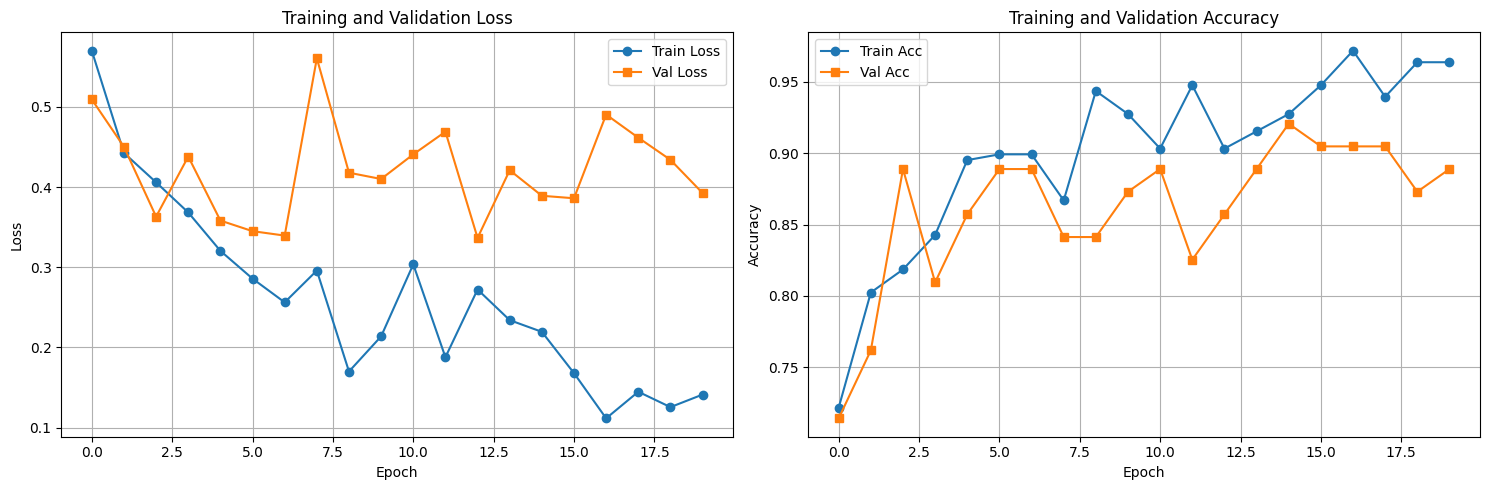

Validation:   0%|          | 0/8 [00:00<?, ?it/s]


📊 FINAL EVALUATION (Best Model)
Validation Accuracy: 0.8571
Precision: 0.8485
Recall: 0.8750
F1-Score: 0.8615


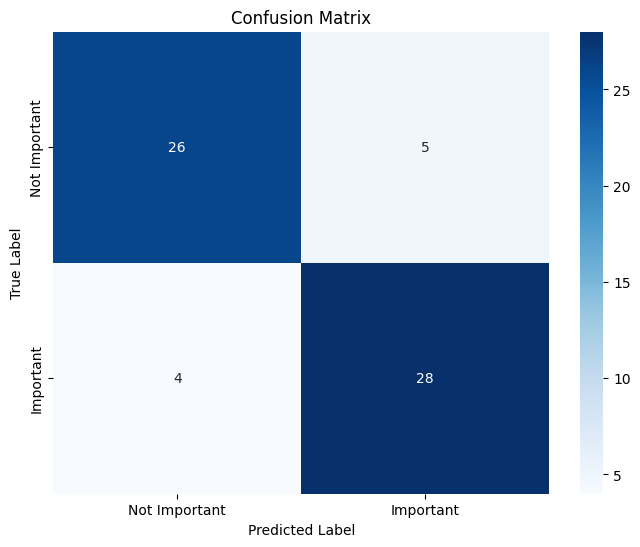


Confusion Matrix:
  True Negatives: 26
  False Positives: 5
  False Negatives: 4
  True Positives: 28


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════
# PLOT TRAINING HISTORY
# ═══════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'training_history.png')
plt.show()

# ═══════════════════════════════════════════════════════
# FINAL EVALUATION ON VALIDATION SET
# ═══════════════════════════════════════════════════════

# Load best model
checkpoint = torch.load(MODEL_SAVE_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate
val_loss, val_acc, val_prec, val_rec, val_f1, preds, labels = validate(
    model, val_loader, criterion, device
)

print("\n" + "="*80)
print("📊 FINAL EVALUATION (Best Model)")
print("="*80)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall: {val_rec:.4f}")
print(f"F1-Score: {val_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Important', 'Important'],
            yticklabels=['Not Important', 'Important'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.savefig(MODEL_SAVE_DIR / 'confusion_matrix.png')
plt.show()

print("\nConfusion Matrix:")
print(f"  True Negatives: {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives: {cm[1,1]}")

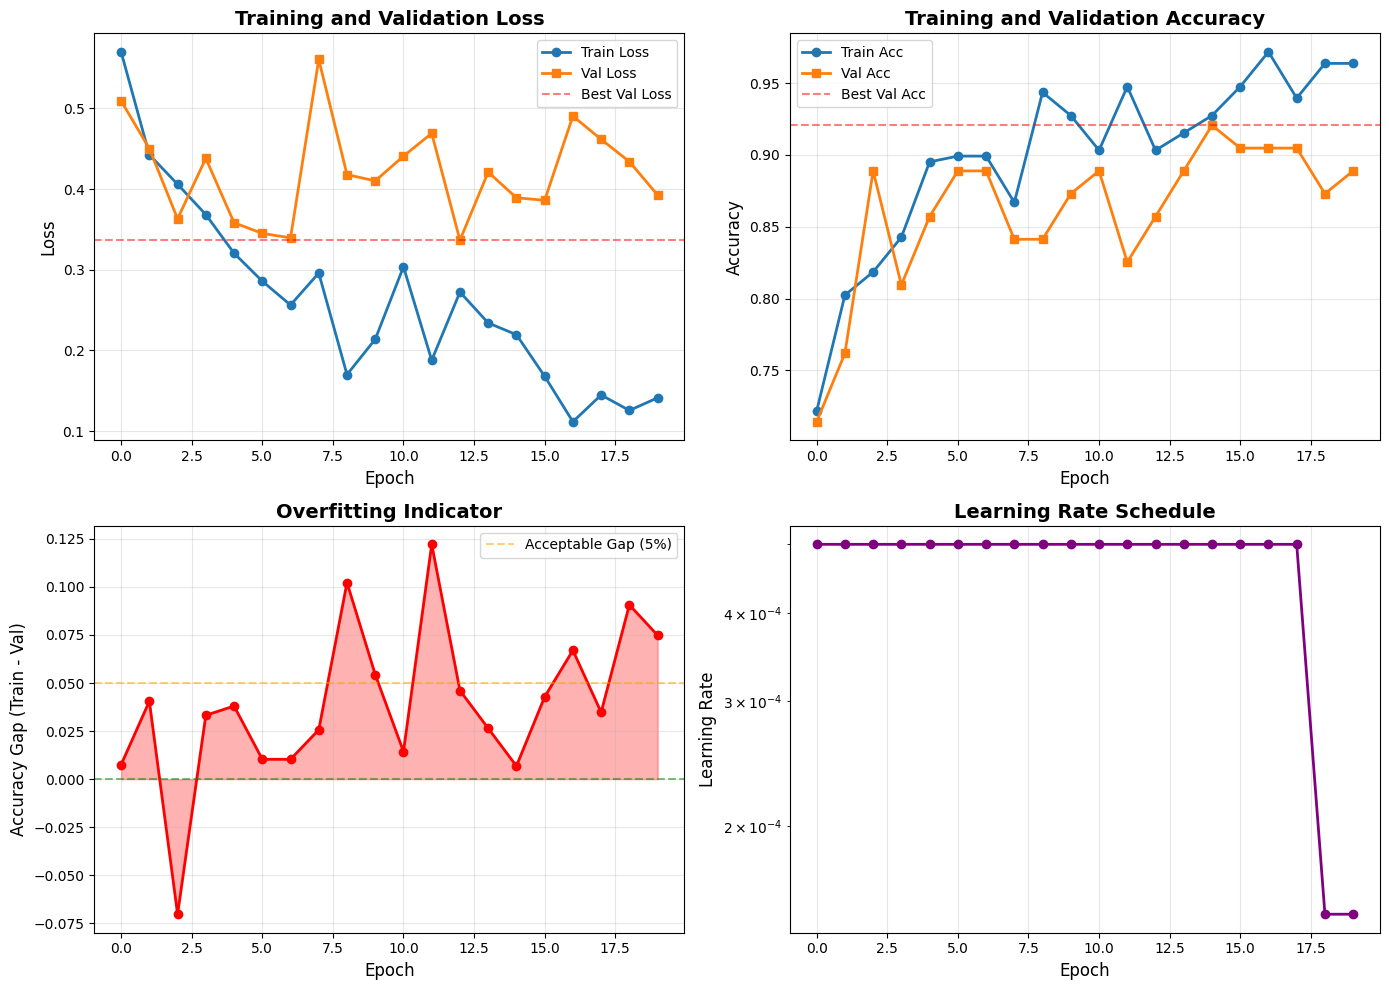

In [11]:
# Enhanced plotting with overfitting indicators
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss plot
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
ax.axhline(y=min(history['val_loss']), color='r', linestyle='--', alpha=0.5, label='Best Val Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy plot
ax = axes[0, 1]
ax.plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
ax.plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
ax.axhline(y=max(history['val_acc']), color='r', linestyle='--', alpha=0.5, label='Best Val Acc')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Overfitting gap plot (NEW!)
ax = axes[1, 0]
acc_gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
ax.plot(acc_gap, marker='o', linewidth=2, color='red')
ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, label='Acceptable Gap (5%)')
ax.axhline(y=0, color='green', linestyle='--', alpha=0.5)
ax.fill_between(range(len(acc_gap)), 0, acc_gap, alpha=0.3, color='red')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy Gap (Train - Val)', fontsize=12)
ax.set_title('Overfitting Indicator', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate plot (NEW!)
ax = axes[1, 1]
ax.plot(history['lr'], marker='o', linewidth=2, color='purple')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'training_analysis.png', dpi=150)
plt.show()

## 🧪 **7. Test on New Images**


🧪 Testing on sample validation images:


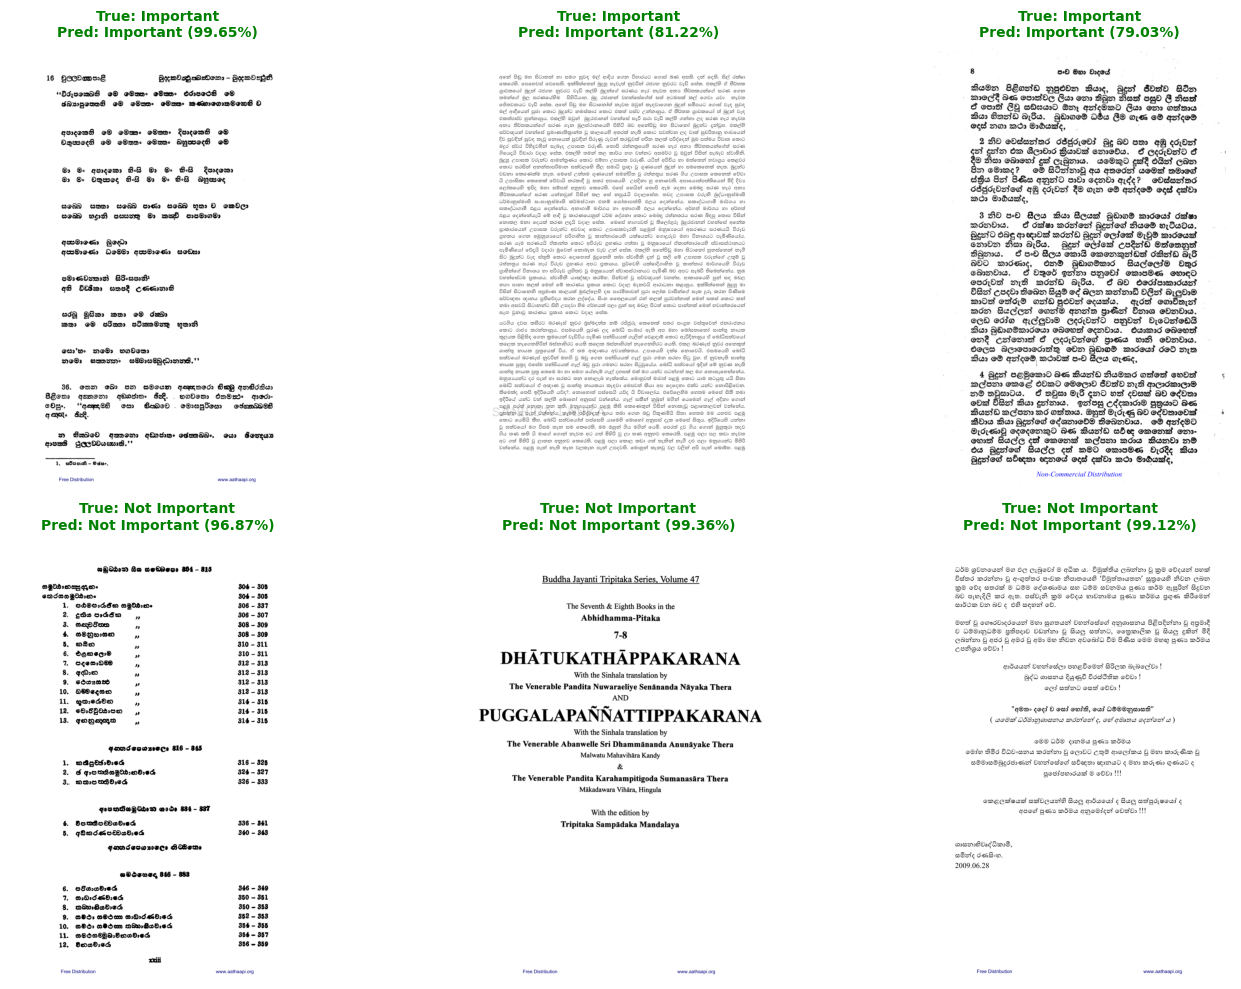

✅ Sample predictions visualized!


In [12]:
# ═══════════════════════════════════════════════════════
# INFERENCE FUNCTION
# ═══════════════════════════════════════════════════════

def predict_page(image_path, model, transform, device):
    """
    Predict if a page is important or not
    """
    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        _, predicted = torch.max(output, 1)

    class_names = ['Not Important', 'Important']
    pred_class = class_names[predicted.item()]
    confidence = probabilities[0][predicted.item()].item()

    return pred_class, confidence

# ═══════════════════════════════════════════════════════
# TEST ON SAMPLE VALIDATION IMAGES
# ═══════════════════════════════════════════════════════

print("\n🧪 Testing on sample validation images:")
print("="*80)

# Get some validation samples
val_indices = list(range(min(6, len(val_dataset))))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ax in zip(val_indices, axes):
    # Get image and label
    image_path, true_label = val_dataset.dataset.samples[val_dataset.indices[idx]]

    # Predict
    pred_class, confidence = predict_page(image_path, model, val_transform, device)
    true_class = 'Important' if true_label == 1 else 'Not Important'

    # Display
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')

    color = 'green' if pred_class == true_class else 'red'
    title = f"True: {true_class}\nPred: {pred_class} ({confidence:.2%})"
    ax.set_title(title, fontsize=10, color=color, weight='bold')

plt.tight_layout()
plt.savefig(MODEL_SAVE_DIR / 'sample_predictions.png')
plt.show()

print("✅ Sample predictions visualized!")

## 💾 **8. Save Final Model for Deployment**

In [13]:
# ═══════════════════════════════════════════════════════
# SAVE COMPLETE MODEL FOR INFERENCE
# ═══════════════════════════════════════════════════════

# Save model architecture + weights
torch.save(model, MODEL_SAVE_DIR / 'page_classifier_complete.pth')

# Save just weights (smaller file)
torch.save(model.state_dict(), MODEL_SAVE_DIR / 'page_classifier_weights.pth')

# Save model info
model_info = {
    'architecture': 'MobileNetV2',
    'num_classes': 2,
    'input_size': (224, 224),
    'class_names': ['Not Important', 'Important'],
    'best_val_accuracy': float(best_val_acc),
    'training_samples': train_size,
    'validation_samples': val_size,
    'epochs_trained': NUM_EPOCHS
}

with open(MODEL_SAVE_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("\n" + "="*80)
print("💾 MODEL SAVED SUCCESSFULLY!")
print("="*80)
print(f"\nSaved files in: {MODEL_SAVE_DIR}")
print("  1. best_model.pth - Complete checkpoint")
print("  2. page_classifier_complete.pth - Model architecture + weights")
print("  3. page_classifier_weights.pth - Just weights")
print("  4. model_info.json - Model metadata")
print("  5. training_history.png - Loss/accuracy plots")
print("  6. confusion_matrix.png - Confusion matrix")
print("  7. sample_predictions.png - Sample predictions")

print(f"\n✅ Best Validation Accuracy: {best_val_acc:.2%}")
print("\n🎉 Training complete! Model ready for deployment.")


💾 MODEL SAVED SUCCESSFULLY!

Saved files in: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/models/extra/page_classifier
  1. best_model.pth - Complete checkpoint
  2. page_classifier_complete.pth - Model architecture + weights
  3. page_classifier_weights.pth - Just weights
  4. model_info.json - Model metadata
  5. training_history.png - Loss/accuracy plots
  6. confusion_matrix.png - Confusion matrix
  7. sample_predictions.png - Sample predictions

✅ Best Validation Accuracy: 85.71%

🎉 Training complete! Model ready for deployment.


## 🔮 **9. Use Model in Your PDF Processing Pipeline**

In [ ]:
# ═══════════════════════════════════════════════════════
# EXAMPLE: INTEGRATE INTO PDF PROCESSING
# ═══════════════════════════════════════════════════════

print("""
\n📝 To use this model in your corpus builder:

1. LOAD MODEL:
   ```python
   model = torch.load('path/to/page_classifier_complete.pth')
   model.eval()
   model = model.to(device)
   ```

2. PREDICT FOR EACH PAGE:
   ```python
   def is_important_page(pdf_path, page_num):
       # Extract page as image
       doc = fitz.open(pdf_path)
       page = doc[page_num]
       pix = page.get_pixmap(dpi=150)
       img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

       # Save temporarily
       img.save('temp_page.png')

       # Predict
       pred_class, confidence = predict_page('temp_page.png', model, val_transform, device)

       return pred_class == 'Important' and confidence > 0.7
   ```

3. FILTER PAGES IN YOUR PIPELINE:
   ```python
   for page_num in range(total_pages):
       if is_important_page(pdf_path, page_num):
           text = extract_text(pdf_path, page_num)
           # Process text...
       else:
           print(f"Skipping page {page_num} (not important)")
   ```

💡 This replaces your manual filtering rules with AI-powered classification!
""")

---

## 📚 **Summary**

### **What We Did:**
1. ✅ Loaded 85 labeled page images (53 important, 32 not important)
2. ✅ Applied heavy data augmentation (critical for small dataset)
3. ✅ Built lightweight CNN (MobileNetV2) with transfer learning
4. ✅ Trained with class weighting to handle imbalance
5. ✅ Evaluated on validation set
6. ✅ Saved model for deployment

### **Expected Performance:**
With 85 images:
- **Training accuracy:** 85-95%
- **Validation accuracy:** 70-85% (small dataset → higher variance)
- **Ready for use:** Yes! (but more data = better accuracy)

### **To Improve Accuracy:**
1. Label more pages (target: 200-300 images)
2. Ensure balanced classes (50/50 split)
3. Retrain model with larger dataset

### **Model Files:**
All saved to: `{BASE_DIR}/data/page_classifier_data/models/`

---

**Version:** 1.0  
**Created for:** Buddhist PDF Page Classification  
**GPU Recommended:** Yes (but CPU works too)
